# Assign random demand to seed point pairs

Steps:
1. Load seed points into list of size N (no. of seed points)
2. Create pair combinations in a new list of size N choose 2 (pair member can be referred to by their index in list 1)
3. Function that assigns random demand to each pair

In [85]:
from typing import List, Tuple

## Compute pairs

We find all possible pairs of seed points with 2-combination, $n$ choose $r$. We assume undirectedness (and just compute total demand for each edge, including travel both ways), so we need unordered pairs withon repetition (because we don't allow self-loops):

$$
{N \choose r} = \frac{N!}{r!(N-r)!}
$$

$$
{N \choose 2} = \frac{N!}{2!(N-2)!}
$$


In [86]:
def pairs(n: int) -> List[Tuple[int, int]]:
    pairs: List[Tuple[int, int]] = []
    for i in range(n):
        for j in range(i+1, n):
            pairs.append((i, j))
    return pairs

In [87]:
S: int = 9 # number of seed points
test_pairs = pairs(S) # n=9 should give 36 unique pairs
print(len(test_pairs))
test_pairs

36


[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (3, 8),
 (4, 5),
 (4, 6),
 (4, 7),
 (4, 8),
 (5, 6),
 (5, 7),
 (5, 8),
 (6, 7),
 (6, 8),
 (7, 8)]

## Generate random demand

In [88]:
import numpy as np
import matplotlib.pyplot as plt

In [89]:
# import secrets
# secrets.randbits(64)

In [90]:
def generate_demand(mean: float, std: float, n: int) -> np.ndarray:
    seed: int = 8920299146682435938
    rng: np.random.Generator = np.random.default_rng(seed=seed)
    return rng.normal(mean, std, size=n)

# Code from NumPy docs
def plot_demand_distribution(mean: float, std: float, demand: np.ndarray):
    count, bins, _ = plt.hist(demand, 30, density=True)
    plt.plot(bins, 1/(std * np.sqrt(2 * np.pi)) *
                   np.exp( - (bins - mean)**2 / (2 * std**2) ),
             linewidth=2, color='r')
    plt.show()

In [91]:
P: int = len(test_pairs) # number of seed point pairs
mean: float = 0.5
std: float = 0.1
test_demand = generate_demand(mean, std, P)
print(type(test_demand))
print(len(test_demand))
print(len(test_demand))
test_demand

<class 'numpy.ndarray'>
36
36


array([0.41622419, 0.42797627, 0.46871791, 0.55599697, 0.47781444,
       0.49492817, 0.67687184, 0.63156416, 0.50617042, 0.44096554,
       0.57618405, 0.53216953, 0.62667603, 0.28256578, 0.66066127,
       0.6505923 , 0.50232399, 0.47034064, 0.53751612, 0.56674942,
       0.48457331, 0.34217347, 0.49590754, 0.55585018, 0.33303848,
       0.65758461, 0.55888272, 0.68096704, 0.37446437, 0.45671717,
       0.45460938, 0.59742719, 0.64743839, 0.37786992, 0.46217563,
       0.58662992])

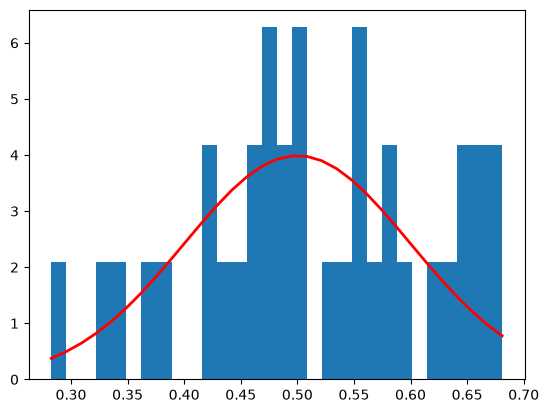

In [92]:
plot_demand_distribution(mean, std, test_demand)

## Map demand to seed point pairs

In [103]:
def total_demand(demand: np.ndarray) -> float:
    return np.sum(demand)    

def normalised_demand(demand: np.ndarray) -> np.ndarray:
    demand_normalised: np.ndarray = np.empty_like(demand)
    total: float = total_demand(demand)
    for i in range(demand.size):
        demand_normalised[i] = (demand[i] * 100) / total
    return demand_normalised

# get the absolute demand for the ith seed point pair
def get_pair_demand_abs(demand: np.ndarray, i: int) -> float:
    return demand[i]

# get the demand percentage for the ith seed point pair
def get_pair_demand_percent(demand: np.ndarray, i: int) -> float:
    return normalised_demand(demand)[i]

# get the total demand that seed point v is involved in
# either 1. store in a map - lookup is cheap, storage is not, or 2. compute it as needed
# here's a naive, expensive version:
def get_point_demand_abs(v: int, pairs: List[Tuple[int,int]], demand: np.ndarray) -> float:
    point_demand: float = 0.0
    for i in range(len(pairs)):
        fst: int = pairs[i][0]
        snd: int = pairs[i][1]
        if v == fst or v == snd:
            point_demand += demand[i]
    return point_demand

# get the total demand share that seed point v is involved in
def get_point_demand_percent(v: int, pairs: List[Tuple[int,int]], demand: np.ndarray) -> float:
    point_demand: float = 0.0
    for i in range(len(pairs)):
        fst: int = pairs[i][0]
        snd: int = pairs[i][1]
        if v == fst or v == snd:
            point_demand += demand[i]
    return (point_demand * 100) / total_demand(demand)


In [104]:
print(f"Total demand: {total_demand(test_demand)}")
test_demand_percent = normalised_demand(test_demand)
print(type(test_demand_percent))
print(len(test_demand_percent))
test_demand_percent

Total demand: 18.569318350256136
<class 'numpy.ndarray'>
36


array([2.24146187, 2.30474947, 2.52415251, 2.99417007, 2.57313936,
       2.66530071, 3.6451087 , 3.40111655, 2.72584277, 2.37469964,
       3.10288207, 2.86585386, 3.37479286, 1.52168093, 3.55781112,
       3.50358741, 2.70512889, 2.53289124, 2.89464647, 3.05207442,
       2.60953744, 1.84268191, 2.6705748 , 2.99337956, 1.79348793,
       3.54124261, 3.00971047, 3.66716229, 2.01657572, 2.45952577,
       2.44817483, 3.21728121, 3.48660288, 2.03491541, 2.48892082,
       3.15913544])

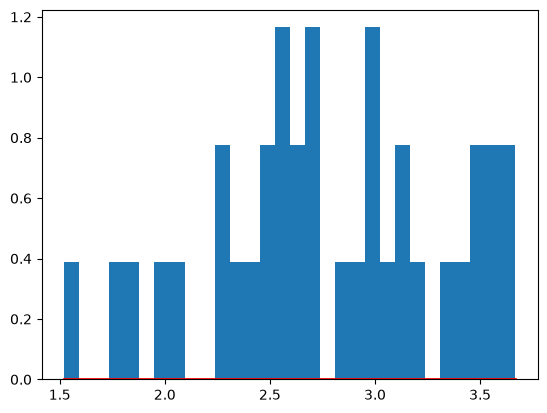

In [105]:
plot_demand_distribution(mean, std, test_demand_percent)

In [106]:
for i in range(P):
    pair = test_pairs[i]
    abs_demand = get_pair_demand_abs(test_demand, i)
    share_demand = get_pair_demand_percent(test_demand, i)
    print(f"Pair: {pair} \t Abs demand: {abs_demand:.2f} \t Share of demand: {share_demand:.2f}")

Pair: (0, 1) 	 Abs demand: 0.42 	 Share of demand: 2.24
Pair: (0, 2) 	 Abs demand: 0.43 	 Share of demand: 2.30
Pair: (0, 3) 	 Abs demand: 0.47 	 Share of demand: 2.52
Pair: (0, 4) 	 Abs demand: 0.56 	 Share of demand: 2.99
Pair: (0, 5) 	 Abs demand: 0.48 	 Share of demand: 2.57
Pair: (0, 6) 	 Abs demand: 0.49 	 Share of demand: 2.67
Pair: (0, 7) 	 Abs demand: 0.68 	 Share of demand: 3.65
Pair: (0, 8) 	 Abs demand: 0.63 	 Share of demand: 3.40
Pair: (1, 2) 	 Abs demand: 0.51 	 Share of demand: 2.73
Pair: (1, 3) 	 Abs demand: 0.44 	 Share of demand: 2.37
Pair: (1, 4) 	 Abs demand: 0.58 	 Share of demand: 3.10
Pair: (1, 5) 	 Abs demand: 0.53 	 Share of demand: 2.87
Pair: (1, 6) 	 Abs demand: 0.63 	 Share of demand: 3.37
Pair: (1, 7) 	 Abs demand: 0.28 	 Share of demand: 1.52
Pair: (1, 8) 	 Abs demand: 0.66 	 Share of demand: 3.56
Pair: (2, 3) 	 Abs demand: 0.65 	 Share of demand: 3.50
Pair: (2, 4) 	 Abs demand: 0.50 	 Share of demand: 2.71
Pair: (2, 5) 	 Abs demand: 0.47 	 Share of deman

In [108]:
for seed_point in range(S):
    abs_demand = get_point_demand_abs(seed_point, test_pairs, test_demand)
    share_demand = get_point_demand_percent(seed_point, test_pairs, test_demand)
    print(f"Seed point: {seed_point} \t Abs demand: {abs_demand:.2f} \t Share of total demand: {share_demand:.2f}")

Seed point: 0 	 Abs demand: 4.15 	 Share of total demand: 22.35
Seed point: 1 	 Abs demand: 4.04 	 Share of total demand: 21.77
Seed point: 2 	 Abs demand: 4.15 	 Share of total demand: 22.33
Seed point: 3 	 Abs demand: 3.94 	 Share of total demand: 21.24
Seed point: 4 	 Abs demand: 4.05 	 Share of total demand: 21.80
Seed point: 5 	 Abs demand: 4.23 	 Share of total demand: 22.80
Seed point: 6 	 Abs demand: 4.19 	 Share of total demand: 22.57
Seed point: 7 	 Abs demand: 3.80 	 Share of total demand: 20.44
Seed point: 8 	 Abs demand: 4.59 	 Share of total demand: 24.70


## Sort pairs after demand